# 02 — Exploratory Data Analysis

## Deep Learning in Asset Pricing — Replication Project

### Purpose of this notebook

This notebook examines the processed datasets created in `01_data_preparation.ipynb` before any asset-pricing model is estimated.

The analysis focuses on:

1. dataset dimensions and time coverage,
2. the number of stock observations available each month,
3. the distribution of monthly stock returns,
4. the distributions and cross-sectional behavior of the 46 firm characteristics,
5. the structure of the 178 macroeconomic predictors,
6. the overlap between the stock and macroeconomic datasets,
7. the chronological training, validation, and test samples.

> This notebook is diagnostic only. It does not change, normalize, winsorize, impute, or otherwise modify the processed replication data.

## 1. Exploratory Analysis Objectives

Before estimating linear, neural-network, LSTM, or adversarial asset-pricing models, it is important to verify the statistical properties of the data that will enter those models.

Exploratory analysis helps identify unexpected gaps, unusual return observations, changes in the cross-sectional number of stocks through time, characteristic distributions that differ from the expected rank-normalized scale, and differences between the stock and macroeconomic sample periods.

The stock-characteristic panel contains 46 firm characteristics and spans January 1967 through December 2016. The processed macroeconomic dataset contains 178 predictors and begins later, in January 1976.

Because the macro dataset starts later than the stock panel, models that combine firm characteristics with macroeconomic information will eventually use the common sample available in both datasets.

## 2. Imports and Reproducibility

This section loads the libraries required for exploratory analysis.

`pandas` and `numpy` are used for tabular and numerical analysis, while `matplotlib` is used for visualization.

A fixed random seed is used whenever we draw a subsample for computationally expensive diagnostics. The underlying processed datasets themselves are never randomly altered.

In [8]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)
print("Seed   :", SEED)

NumPy  : 2.5.3
pandas : 3.0.5
Seed   : 42


## 3. Locate the Repository and Load the Processed Data

To keep the replication reproducible, this notebook avoids hard-coded user-specific paths.

Instead of referring directly to a location such as

`/Users/reza/Desktop/...`

the notebook automatically searches upward from the current working directory until it finds the project root.

The project root is identified using either:

- the `.git` directory, or
- the `requirements.txt` file.

Once the repository root is located, the notebook defines the main directories used in the exploratory analysis:

- `data/processed/` for the cleaned datasets created in `01_data_preparation.ipynb`,
- `results/figures/` for plots generated during exploratory analysis,
- `results/tables/` for summary tables and diagnostics.

This design makes the notebook portable across different computers and collaborators because the code does not depend on a specific local folder path.

The required output directories are also created automatically if they do not already exist.

The next step in this section loads the two processed datasets:

- `retchar_processed.parquet`
- `macro_processed.parquet`

Using the processed Parquet files ensures that the exploratory analysis is based on exactly the same inputs that will later be used for model estimation.

In [9]:
def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "requirements.txt").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root. Open Jupyter from inside the cloned repository."
    )

ROOT = find_repo_root()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root :", ROOT)
print("Processed data  :", PROCESSED_DIR)
print("Figures         :", FIGURES_DIR)
print("Tables          :", TABLES_DIR)

Repository root : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project
Processed data  : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/processed
Figures         : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/figures
Tables          : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables


In [10]:
RETCHAR_PATH = PROCESSED_DIR / "retchar_processed.parquet"
MACRO_PATH = PROCESSED_DIR / "macro_processed.parquet"

if not RETCHAR_PATH.exists():
    raise FileNotFoundError(f"{RETCHAR_PATH.name} not found. Run 01_data_preparation.ipynb first.")

if not MACRO_PATH.exists():
    raise FileNotFoundError(f"{MACRO_PATH.name} not found. Run 01_data_preparation.ipynb first.")

stock = pd.read_parquet(RETCHAR_PATH)
macro = pd.read_parquet(MACRO_PATH)

print(f"Stock data: {stock.shape[0]:,} rows × {stock.shape[1]:,} columns")
print(f"Macro data: {macro.shape[0]:,} rows × {macro.shape[1]:,} columns")

Stock data: 1,218,555 rows × 48 columns
Macro data: 600 rows × 179 columns


## 4. Identify the Data Structure

Before performing exploratory analysis, we identify the key variables in the processed stock and macroeconomic datasets.

For the stock-characteristic dataset, we need to determine:

- the monthly date column,
- the monthly return column,
- the 46 firm-characteristic columns.

For the macroeconomic dataset, we identify:

- the monthly date column,
- the 178 macroeconomic predictor columns.

The helper function searches for common naming conventions for the date and return variables so that the notebook remains robust to small differences in column names.

After identifying the date and return fields, all remaining numeric columns in the stock dataset are treated as firm characteristics.

Similarly, all numeric columns in the macro dataset other than the date column are treated as macroeconomic predictors.

This step verifies that the processed datasets have the expected structure before any descriptive analysis is performed.

For this replication, we expect to confirm:

- 46 firm characteristics in the stock dataset,
- 178 macroeconomic predictors in the macro dataset.

Matching these dimensions is an important consistency check because they correspond to the input structure used in the replication framework.

In [11]:
def detect_column(columns, candidates, label):
    cols = list(columns)
    for c in candidates:
        if c in cols:
            return c
    raise KeyError(f"Could not detect {label}. Tried {candidates}. Available columns begin with {cols[:20]}")

DATE_COL = detect_column(stock.columns, ["date", "yyyymm", "month", "caldt", "time"], "stock date")
RET_COL = detect_column(stock.columns, ["ret", "return", "ret_excess", "excess_ret", "retx"], "return")
MACRO_DATE_COL = detect_column(macro.columns, ["date", "yyyymm", "month", "caldt", "time"], "macro date")

characteristic_cols = [
    c for c in stock.columns
    if c not in [DATE_COL, RET_COL] and pd.api.types.is_numeric_dtype(stock[c])
]

macro_feature_cols = [
    c for c in macro.columns
    if c != MACRO_DATE_COL and pd.api.types.is_numeric_dtype(macro[c])
]

print("Stock date column        :", DATE_COL)
print("Return column            :", RET_COL)
print("Firm characteristics     :", len(characteristic_cols))
print("Macro date column        :", MACRO_DATE_COL)
print("Macroeconomic predictors :", len(macro_feature_cols))

Stock date column        : date
Return column            : ret
Firm characteristics     : 46
Macro date column        : date
Macroeconomic predictors : 178


## 5. Dataset Overview and Time Coverage

After identifying the variables in each dataset, we summarize their overall dimensions and time coverage.

For both the stock-characteristic and macroeconomic datasets, this section reports:

- the total number of observations,
- the number of columns,
- the number of unique months,
- the first month in the dataset,
- the last month in the dataset.

This provides a compact overview of the empirical sample and helps verify that the processed files match the results obtained in the data-preparation notebook.

For the stock-characteristic dataset, we expect the sample to span:

\[
\text{January 1967 to December 2016},
\]

corresponding to 600 monthly periods.

The macroeconomic dataset begins later, in January 1976, and continues through December 2016.

Therefore, the macroeconomic dataset contains fewer monthly observations than the stock-characteristic panel.

This difference in time coverage is important because models that use only firm characteristics may use the full stock sample, while models that also use macroeconomic information will eventually be restricted to the period in which both datasets are available.

At this stage, the objective is only to document the available sample rather than modify or align the datasets.

In [12]:
overview = pd.DataFrame([
    {
        "dataset": "Stock characteristics",
        "rows": len(stock),
        "columns": stock.shape[1],
        "months": stock[DATE_COL].nunique(),
        "start": stock[DATE_COL].min(),
        "end": stock[DATE_COL].max(),
    },
    {
        "dataset": "Macro",
        "rows": len(macro),
        "columns": macro.shape[1],
        "months": macro[MACRO_DATE_COL].nunique(),
        "start": macro[MACRO_DATE_COL].min(),
        "end": macro[MACRO_DATE_COL].max(),
    },
])

display(overview)

,dataset,rows,columns,months,start,end
0,Stock characteristics,1218555,48,600,1967-01-01,2016-12-01
1,Macro,600,179,600,1967-01-01,2016-12-01


## 6. Cross-Sectional Number of Stock Observations Through Time

The processed stock dataset does not contain a stock identifier such as `PERMNO`, so individual firms cannot be followed through time.

However, each row represents one stock-month observation. Therefore, counting the number of observations within each month provides the size of the cross-sectional stock sample available to the model.

This diagnostic helps us understand how the investment universe evolves over time.

Changes in the monthly number of observations may reflect:

- changes in the number of listed firms,
- entry and exit of firms from the sample,
- differences in data availability,
- sample-construction rules used in the original processed dataset.

A smoothly evolving cross-sectional count would generally be expected, while abrupt or unexplained jumps could indicate data-quality or preprocessing issues.

This section therefore summarizes the monthly number of stock observations and visualizes its evolution from 1967 through 2016.

In [14]:
monthly_stock_counts = (
    stock.groupby(DATE_COL)
    .size()
    .rename("stock_observations")
    .to_frame()
)

display(monthly_stock_counts.describe().T)

print("Minimum monthly observations:", f"{monthly_stock_counts['stock_observations'].min():,}")
print("Maximum monthly observations:", f"{monthly_stock_counts['stock_observations'].max():,}")
print("Median monthly observations :", f"{monthly_stock_counts['stock_observations'].median():,.0f}")

,count,mean,std,min,25%,50%,75%,max
stock_observations,600.000000,"2,030.925000",609.848701,430.000000,"1,400.000000","2,185.000000","2,596.750000","2,826.000000"


Minimum monthly observations: 430
Maximum monthly observations: 2,826
Median monthly observations : 2,185


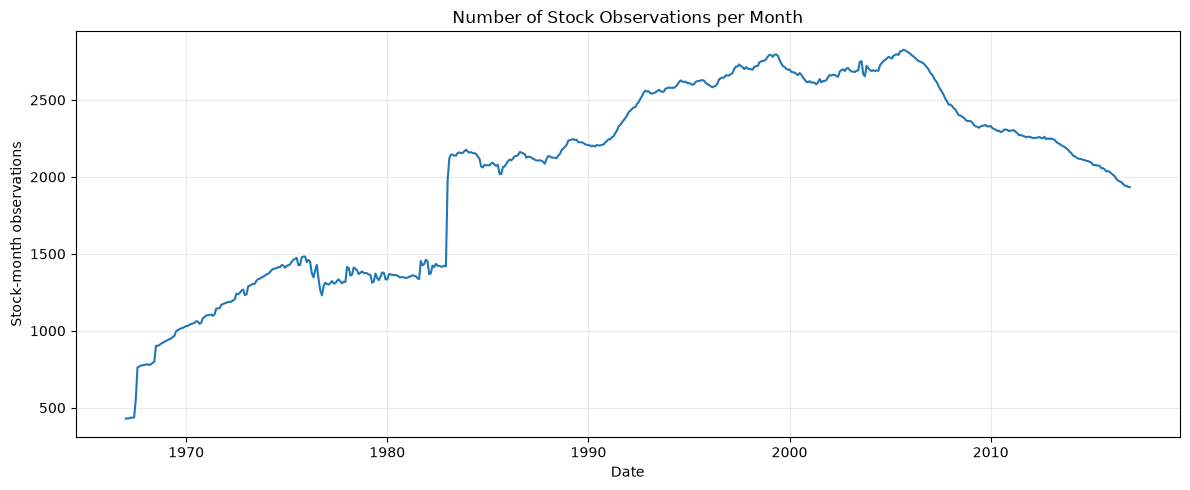

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_stock_counts.index, monthly_stock_counts["stock_observations"])
plt.title("Number of Stock Observations per Month")
plt.xlabel("Date")
plt.ylabel("Stock-month observations")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation

The monthly size of the stock cross-section varies considerably over the sample.

The number of stock-month observations ranges from 430 to 2,826, with a median of 2,185 observations per month.

This variation is economically plausible for a long historical sample because the number of publicly listed firms and the availability of firm-level information change over time.

The result also confirms that the dataset is an unbalanced panel: the cross-sectional number of stocks is not constant from month to month.

No obvious issue is indicated by the summary statistics alone, but the time-series plot should also be inspected for abrupt or unexplained discontinuities.

## 7. Monthly Stock Return Distribution

We examine the distribution of monthly stock returns to understand its center, dispersion, skewness, heavy tails, and extreme observations.

At this stage, extreme observations are documented rather than winsorized or removed. Any modification of returns would be an additional preprocessing choice and should not be introduced silently during exploratory analysis.

In [16]:
return_summary = stock[RET_COL].describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
)

display(return_summary.to_frame(name=RET_COL))

print("Return skewness:", f"{stock[RET_COL].skew():.4f}")
print("Return kurtosis:", f"{stock[RET_COL].kurt():.4f}")

,ret
count,"1,218,555.000000"
mean,0.009855
std,0.161131
min,-0.960633
0.1%,-0.567966
1%,-0.348642
5%,-0.201836
25%,-0.066344
50%,-0.001946
75%,0.070704


Return skewness: 5.9775
Return kurtosis: 304.6091


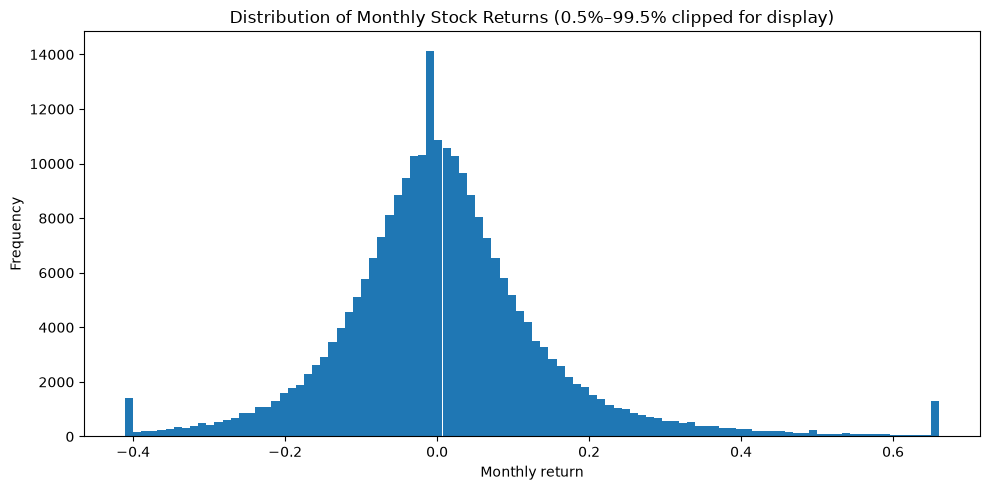

Clipping above is used only for visualization; the underlying data are unchanged.


In [17]:
plot_n = min(250_000, len(stock))
return_plot_sample = stock[RET_COL].sample(n=plot_n, random_state=SEED)

q_low, q_high = return_plot_sample.quantile([0.005, 0.995])

plt.figure(figsize=(10, 5))
plt.hist(return_plot_sample.clip(q_low, q_high), bins=100)
plt.title("Distribution of Monthly Stock Returns (0.5%–99.5% clipped for display)")
plt.xlabel("Monthly return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Clipping above is used only for visualization; the underlying data are unchanged.")

### Interpretation

The monthly stock-return distribution is highly non-normal.

The average monthly return is approximately 0.99%, while the median return is slightly negative at approximately -0.19%. The fact that the mean is substantially larger than the median indicates a positively skewed distribution.

This is confirmed by the skewness statistic of approximately 5.98.

The return distribution also exhibits extremely heavy tails. The kurtosis is approximately 304.6, which is far above the value associated with a normal distribution.

The lower tail includes returns close to -100%, while the upper tail contains a small number of extremely large positive observations. In particular, the maximum observed monthly return is approximately 18.9975, corresponding to almost a 1,900% return.

These extreme observations are important for asset-pricing applications because they can strongly influence sample moments, portfolio returns, and model estimation.

At this exploratory stage, we do not remove or winsorize these observations. Instead, we preserve the processed replication data as supplied and document the heavy-tailed behavior of the return distribution.

In [18]:
# Inspect the largest and smallest return observations

print("Largest returns:")
display(
    stock[[DATE_COL, RET_COL]]
    .sort_values(RET_COL, ascending=False)
    .head(10)
)

print("\nSmallest returns:")
display(
    stock[[DATE_COL, RET_COL]]
    .sort_values(RET_COL)
    .head(10)
)

Largest returns:


,date,ret
517525,1993-08-01,18.997500
558504,1994-12-01,12.495600
414582,1990-01-01,10.994300
725923,2000-02-01,10.339700
684799,1998-11-01,9.370527
447003,1991-03-01,8.995600
511118,1993-06-01,7.477500
1016733,2009-04-01,7.007379
599540,1996-04-01,6.995400
853866,2004-02-01,6.907472



Smallest returns:


,date,ret
490680,1992-10-01,-0.960633
975071,2007-11-01,-0.956084
764433,2001-05-01,-0.955903
514960,1993-07-01,-0.952400
994138,2008-07-01,-0.946167
654421,1997-12-01,-0.942300
454150,1991-07-01,-0.933471
1000354,2008-09-01,-0.932927
744307,2000-09-01,-0.931802
464977,1991-11-01,-0.920567


### Extreme Return Observations

The stock-return distribution contains a small number of very large positive and negative observations.

The largest monthly return in the sample is approximately 18.9975, corresponding to a return of about 1,900%. Several other observations exceed 500%.

The lower tail is bounded much closer to -1, with the most negative monthly return approximately -0.961, corresponding to a loss of about 96%.

This asymmetry helps explain the strong positive skewness and extremely high kurtosis observed in the return distribution.

Because the processed dataset does not include a stock identifier, these observations cannot be linked to individual securities within the current replication data.

At this stage, the extreme returns are retained exactly as supplied. Removing, winsorizing, or truncating them would constitute an additional preprocessing decision and could move the replication away from the intended input data.

Their presence should nevertheless be kept in mind during later model estimation because extreme returns can have a large influence on loss functions, portfolio returns, and estimated stochastic discount factor weights.

In [19]:
# Frequency of extreme monthly returns

extreme_summary = pd.Series({
    "ret > 100%": (stock[RET_COL] > 1.0).sum(),
    "ret > 200%": (stock[RET_COL] > 2.0).sum(),
    "ret > 500%": (stock[RET_COL] > 5.0).sum(),
    "ret < -50%": (stock[RET_COL] < -0.5).sum(),
    "ret < -80%": (stock[RET_COL] < -0.8).sum(),
    "ret < -90%": (stock[RET_COL] < -0.9).sum(),
})

display(extreme_summary.to_frame("count"))

,count
ret > 100%,1915
ret > 200%,281
ret > 500%,22
ret < -50%,2583
ret < -80%,78
ret < -90%,14


### Frequency of Extreme Returns

The extreme-return counts confirm that unusually large monthly stock returns are present in the sample but are concentrated in a relatively small number of observations.

On the positive side:

- 1,915 observations exceed a 100% monthly return,
- 281 observations exceed 200%,
- 22 observations exceed 500%.

On the negative side:

- 2,583 observations are below -50%,
- 78 observations are below -80%,
- 14 observations are below -90%.

These results reinforce the earlier evidence of a highly non-normal return distribution.

The positive tail is particularly pronounced, which contributes to the strong positive skewness observed in the sample. At the same time, the downside tail contains a meaningful number of very large losses.

Because these observations are part of the supplied replication dataset, they are retained without winsorization or truncation.

Their influence should be kept in mind when interpreting later asset-pricing losses, SDF portfolio returns, and model-performance statistics.

## 8. Returns Across Training, Validation, and Test Periods

We compare the return distribution across the fixed chronological samples:

- training: 1967–1986,
- validation: 1987–1991,
- test: 1992–2016.

This is descriptive only. Test-period statistics are not used to tune the models.

In [20]:
TRAIN_START = pd.Timestamp("1967-01-01")
TRAIN_END = pd.Timestamp("1986-12-31")
VALID_START = pd.Timestamp("1987-01-01")
VALID_END = pd.Timestamp("1991-12-31")
TEST_START = pd.Timestamp("1992-01-01")
TEST_END = pd.Timestamp("2016-12-31")

def label_split(date):
    if TRAIN_START <= date <= TRAIN_END:
        return "train"
    if VALID_START <= date <= VALID_END:
        return "validation"
    if TEST_START <= date <= TEST_END:
        return "test"
    return "outside"

stock_eda = stock[[DATE_COL, RET_COL]].copy()
stock_eda["split"] = stock_eda[DATE_COL].map(label_split)

return_by_split = stock_eda.groupby("split")[RET_COL].agg(
    ["count", "mean", "std", "median", "min", "max"]
)

display(return_by_split.loc[
    [x for x in ["train", "validation", "test"] if x in return_by_split.index]
])

,count,mean,std,median,min,max
split,,,,,,
train,336113,0.007283,0.128763,-0.004600,-0.855500,5.244800
validation,132167,0.006807,0.165991,-0.004700,-0.933471,10.994300
test,750275,0.011544,0.172856,0.000984,-0.960633,18.997500


### Interpretation

The return distribution differs noticeably across the training, validation, and test periods.

The training sample has an average monthly return of approximately 0.73% and the lowest return volatility, with a standard deviation of about 12.9%.

The validation sample has a slightly lower average return of approximately 0.68%, but substantially higher volatility of about 16.6%.

The test sample has the highest average monthly return, approximately 1.15%, and the highest volatility, approximately 17.3%.

The median return is slightly negative in both the training and validation samples, while it becomes slightly positive in the test period.

The extreme observations also become larger in magnitude over time. The maximum monthly return increases from approximately 5.24 in the training sample to 10.99 in validation and 19.00 in the test sample. Similarly, the most negative return becomes more severe in the later periods.

These differences indicate that the return distribution is not stable across the full 1967–2016 sample.

This is important for the replication because the models are trained primarily on an earlier, less volatile period and then evaluated on a later period with greater dispersion and more extreme observations.

Therefore, the out-of-sample test represents a meaningful challenge for the asset-pricing models rather than simply reproducing the same distribution observed during training.


One useful conclusion from Part 8 is:
$$ \sigma_{\text{train}} \approx 12.9\% < \sigma_{\text{validation}} \approx 16.6\% < \sigma_{\text{test}} \approx 17.3\%. $$
That is worth remembering later when comparing the linear model, neural network, LSTM, and GAN out-of-sample performance.

## 9. Firm-Characteristic Summary Statistics

The stock panel contains 46 firm characteristics. Because the supplied characteristics are already rank-normalized, their values should remain approximately within

\[
[-0.5, 0.5].
\]

For each characteristic, we calculate its mean, standard deviation, minimum, selected percentiles, and maximum.

In [22]:
char_summary = stock[characteristic_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(char_summary)

print(
    "Overall characteristic range:",
    f"[{stock[characteristic_cols].min().min():.6f}, "
    f"{stock[characteristic_cols].max().max():.6f}]"
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
a2me,"1,218,555.000000",0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
ac,"1,218,555.000000",-0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
at,"1,218,555.000000",-0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
ato,"1,218,555.000000",-0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
beme,"1,218,555.000000",-0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
beta,"1,218,555.000000",0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
c,"1,218,555.000000",0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
cf,"1,218,555.000000",0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
cf2p,"1,218,555.000000",-0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000
cto,"1,218,555.000000",-0.000000,0.288817,-0.500000,-0.490243,-0.450219,-0.250114,0.000000,0.250114,0.450219,0.490243,0.500000


Overall characteristic range: [-0.500000, 0.500000]


### Interpretation

The firm-characteristic summary confirms that the 46 predictors are already expressed on a common normalized scale.

The values remain approximately within the interval

\[$
[-0.5,\,0.5],$
\]

which is consistent with the cross-sectional rank-normalization used in the processed replication data.

This common scale is useful for later machine-learning models because the neural networks do not need to learn across variables measured in very different units.

The summary statistics also provide a first check for unusual characteristics with extremely low variation, asymmetric distributions, or values outside the expected normalized range.

At this stage, no additional transformation is applied. The characteristic values are preserved exactly as supplied.

| Variable     | Full name / meaning                                                                      |
| ------------ | ---------------------------------------------------------------------------------------- |
| `a2me`       | **Assets to Market Equity/Market Cap** — total assets relative to market capitalization  |
| `ac`         | **Accruals** — accounting accrual component of earnings                                  |
| `at`         | **Total Assets** — firm asset size                                                       |
| `ato`        | **Asset Turnover / Net Sales to Lagged Net Operating Assets**                            |
| `beme`       | **Book-to-Market Equity** — book equity relative to market equity                        |
| `beta`       | **CAPM Beta** — sensitivity of the stock return to market returns                        |
| `c`          | **Cash Ratio** — cash and short-term investments relative to total assets                |
| `cf`         | **Free Cash Flow to Book Value**                                                         |
| `cf2p`       | **Cash Flow to Price**                                                                   |
| `cto`        | **Capital Turnover**                                                                     |
| `d2a`        | **Capital Intensity**                                                                    |
| `d2p`        | **Dividend Yield** — dividends relative to price                                         |
| `dpi2a`      | **Change in Property, Plant & Equipment relative to Assets**                             |
| `e2p`        | **Earnings-to-Price Ratio**                                                              |
| `fc2y`       | **Fixed Costs to Sales**                                                                 |
| `idiovol`    | **Idiosyncratic Volatility** — stock volatility unexplained by systematic market factors |
| `investment` | **Investment** — firm investment/growth measure                                          |
| `lev`        | **Leverage**                                                                             |
| `lme`        | **Size** — market-equity/market-cap size measure                                         |
| `lt_rev`     | **Long-Term Reversal**                                                                   |
| `lturnover`  | **Turnover** — trading turnover/liquidity measure                                        |
| `mktbeta`    | **Market Beta**                                                                          |
| `ni`         | **Net Share Issues**                                                                     |
| `noa`        | **Net Operating Assets**                                                                 |
| `oa`         | **Operating Accruals**                                                                   |
| `ol`         | **Operating Leverage**                                                                   |
| `op`         | **Operating Profitability**                                                              |
| `pcm`        | **Price-to-Cost Margin**                                                                 |
| `pm`         | **Profit Margin**                                                                        |
| `prof`       | **Profitability**                                                                        |
| `q`          | **Tobin's Q**                                                                            |
| `r2_1`       | **Short-Term Momentum** — return signal using recent past returns                        |
| `r12_2`      | **Momentum** — approximately months 2–12 past return                                     |
| `r12_7`      | **Intermediate Momentum**                                                                |
| `r36_13`     | **Long-Term Momentum**                                                                   |
| `rel2high`   | **Closeness to Past-Year High** — price relative to its previous 52-week high            |
| `resid_var`  | **Residual Variance**                                                                    |
| `rna`        | **Return on Net Operating Assets**                                                       |
| `roa`        | **Return on Assets**                                                                     |
| `roe`        | **Return on Equity**                                                                     |
| `s2p`        | **Sales-to-Price Ratio**                                                                 |
| `sga2s`      | **Selling, General & Administrative Expenses to Sales**                                  |
| `spread`     | **Bid-Ask Spread** — trading-friction/liquidity measure                                  |
| `st_rev`     | **Short-Term Reversal**                                                                  |
| `suv`        | **Standardized Unexplained Volume**                                                      |
| `variance`   | **Return Variance**                                                                      |


## 10. Selected Firm-Characteristic Distributions

The summary statistics in Part 9 confirm that the 46 firm characteristics are already cross-sectionally rank-normalized.

In this section, we visually inspect a representative subset of the characteristics to verify that their empirical distributions are consistent with the expected normalized scale.

The selected variables include:

- `a2me` — assets relative to market equity,
- `beme` — book-to-market equity,
- `beta` — systematic market-risk measure,
- `idiovol` — idiosyncratic volatility,
- `lev` — leverage,
- `r12_2` — medium-term momentum.

Because the characteristics have been ranked cross-sectionally within each month and centered around zero, we expect their values to remain approximately within

\[
[-0.5, 0.5].
\]

The distributions should also appear relatively well spread across this interval.

This visual inspection provides an additional check that the processed characteristics have the expected scale and that no variable exhibits unexpected concentration, missing regions, or values outside the intended range.

No transformation is performed in this section. The plots are used only for exploratory analysis.

In [23]:
preferred_characteristics = ["a2me", "beme", "beta", "idiovol", "lev", "r12_2"]

selected_characteristics = [
    c for c in preferred_characteristics if c in characteristic_cols
]

if len(selected_characteristics) < 6:
    for c in characteristic_cols:
        if c not in selected_characteristics:
            selected_characteristics.append(c)
        if len(selected_characteristics) == 6:
            break

print("Selected characteristics:", selected_characteristics)

Selected characteristics: ['a2me', 'beme', 'beta', 'idiovol', 'lev', 'r12_2']


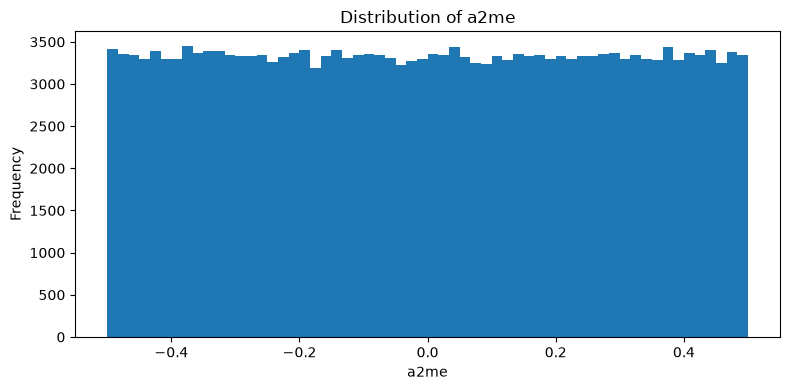

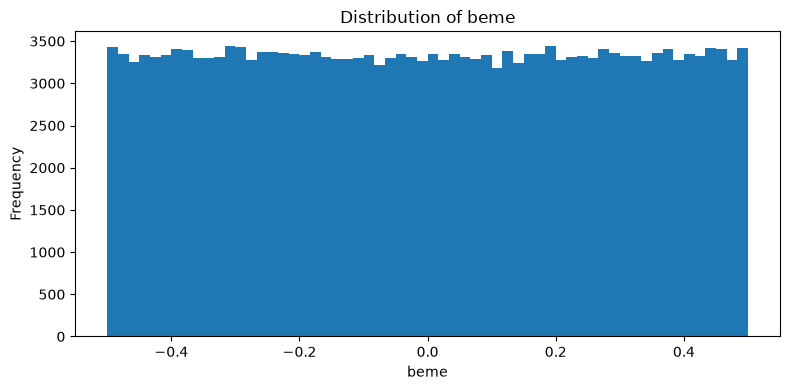

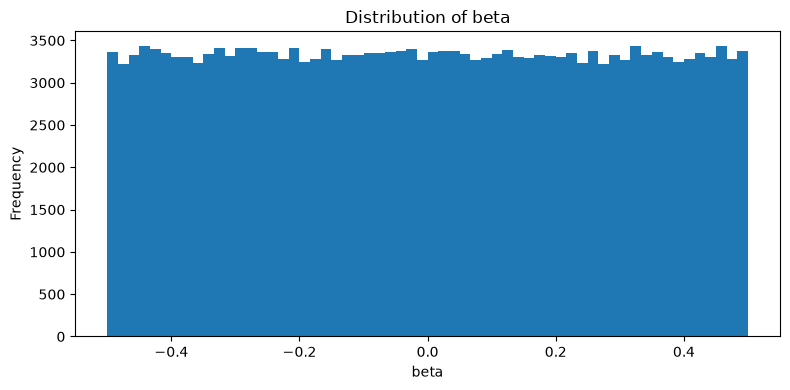

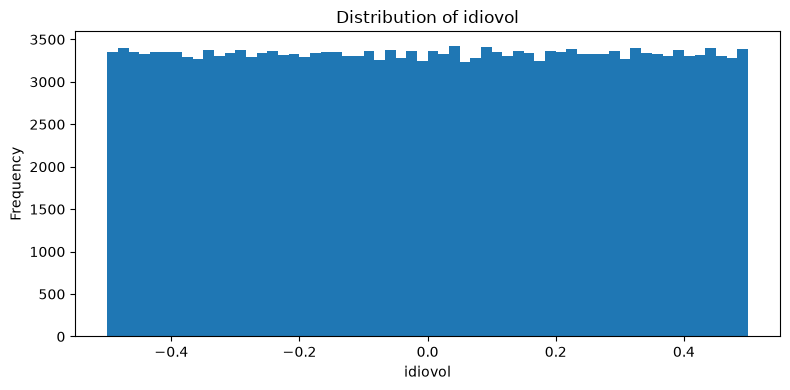

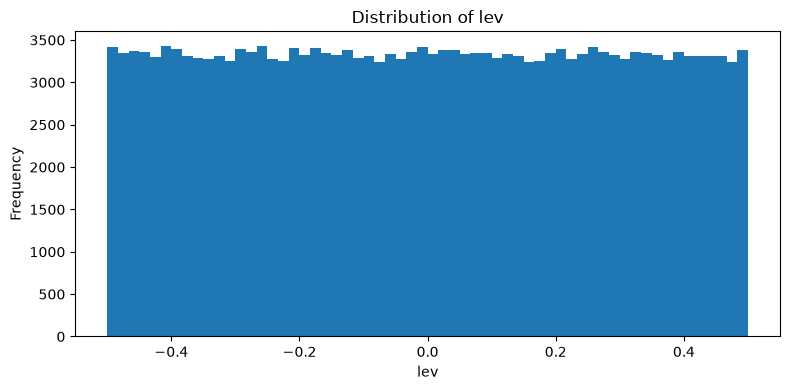

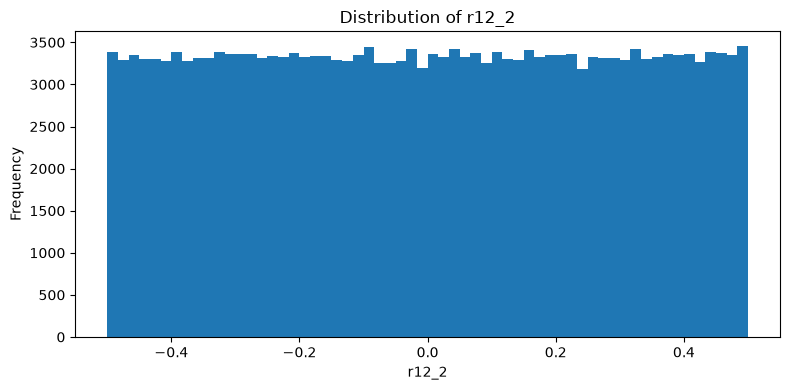

In [24]:
plot_n = min(200_000, len(stock))
char_plot_sample = stock[selected_characteristics].sample(n=plot_n, random_state=SEED)

for c in selected_characteristics:
    plt.figure(figsize=(8, 4))
    
    plt.hist(char_plot_sample[c], bins=60)
    
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Interpretation

The selected firm characteristics are distributed across approximately the interval

\[
[-0.5, 0.5].
\]

This is consistent with the rank-normalized structure of the processed replication data.

The distributions are broadly spread across the available range, indicating that the variables preserve substantial cross-sectional variation even after normalization.

Small deviations from a perfectly uniform distribution can arise from ties in the underlying raw characteristics and from changes in the number of stocks available in each month.

Overall, the plots provide additional confirmation that the selected firm characteristics have the expected normalized scale and are suitable as inputs to the later asset-pricing models.

## 11. Cross-Sectional Characteristic Behavior Through Time

The 46 firm characteristics in the supplied dataset are already rank-normalized within each month.

If the normalization is working as intended, the cross-sectional distribution of each characteristic should remain on a relatively stable scale through time.

In particular, for each month and each characteristic, we examine:

- the cross-sectional mean,
- the cross-sectional standard deviation.

Because the characteristics are centered around zero, the monthly cross-sectional mean should generally remain close to zero.

Similarly, the monthly cross-sectional standard deviation should be relatively stable over time if the rank transformation is applied consistently.

This diagnostic helps identify:

- characteristics whose monthly distributions may shift unexpectedly,
- possible inconsistencies in preprocessing,
- variables with unusually low or unstable cross-sectional variation.

The objective is not to modify the characteristics, but to confirm that the processed inputs behave consistently across the full sample period.

In [25]:
monthly_char_mean = stock.groupby(DATE_COL)[characteristic_cols].mean()
monthly_char_std = stock.groupby(DATE_COL)[characteristic_cols].std()

char_time_diagnostics = pd.DataFrame({
    "avg_abs_monthly_mean": monthly_char_mean.abs().mean(),
    "avg_monthly_std": monthly_char_std.mean(),
    "min_monthly_std": monthly_char_std.min(),
    "max_monthly_std": monthly_char_std.max(),
}).sort_values("avg_abs_monthly_mean", ascending=False)

display(char_time_diagnostics)

,avg_abs_monthly_mean,avg_monthly_std,min_monthly_std,max_monthly_std
beta,0.000000,0.288920,0.288828,0.289684
cto,0.000000,0.288920,0.288828,0.289684
resid_var,0.000000,0.288920,0.288828,0.289684
st_rev,0.000000,0.288920,0.288828,0.289684
sga2s,0.000000,0.288920,0.288828,0.289684
r36_13,0.000000,0.288920,0.288828,0.289684
noa,0.000000,0.288920,0.288828,0.289684
cf2p,0.000000,0.288920,0.288828,0.289684
ac,0.000000,0.288920,0.288828,0.289684
q,0.000000,0.288920,0.288828,0.289684


### avg_abs_monthly_mean = 0.000000


### avg_monthly_std      ≈ 0.288920

### min_monthly_std      ≈ 0.288828

### max_monthly_std      ≈ 0.289684

### Interpretation

The time-series diagnostics provide strong confirmation that the 46 firm characteristics were consistently cross-sectionally rank-normalized in the supplied dataset.

For every characteristic, the average absolute monthly cross-sectional mean is effectively zero.

This indicates that the characteristics are centered around zero within each month.

The average monthly cross-sectional standard deviation is approximately
\[
0.289,
\]
which is extremely close to the theoretical standard deviation of a uniformly distributed variable on

\[
[-0.5,0.5],
\]

given by

\[$
\sqrt{\frac{1}{12}}
\approx 0.2887.$
\]

The minimum and maximum monthly standard deviations are also tightly concentrated around this value, indicating that the scaling procedure is highly stable throughout the 1967–2016 sample.

These results provide strong evidence that the characteristic transformation was applied consistently across both variables and time.

Therefore, no additional normalization is required before the characteristics are used as inputs to the asset-pricing models.

## 12. Correlation Among Firm Characteristics

The 46 firm characteristics enter the later asset-pricing models jointly.

Even though neural networks can capture nonlinear relationships, it is still useful to examine the linear correlation structure among the inputs.

This diagnostic helps identify:

- characteristics that contain very similar information,
- groups of variables that move together,
- potentially redundant predictors,
- variables that are largely independent from the rest of the characteristic set.

Because the stock dataset contains more than 1.2 million observations, computing the correlation matrix on the full sample is unnecessary for exploratory purposes.

Instead, we draw a fixed random subsample and calculate the pairwise correlation matrix using that sample.

The subsample is used only for this diagnostic. It does not alter the underlying processed data and it will not be used to define the training sample.

After computing the correlation matrix, we also identify the characteristic pairs with the largest absolute correlations.

This provides a compact way to see where the strongest linear dependence exists among the 46 predictors.

In [27]:
# 12. Correlation among firm characteristics

corr_n = min(200_000, len(stock))

corr_sample = stock[
    characteristic_cols
].sample(
    n=corr_n,
    random_state=SEED
)

char_corr = corr_sample.corr()

display(char_corr.round(3))

,a2me,ac,at,ato,beme,beta,c,cf,cf2p,cto,d2a,d2p,dpi2a,e2p,fc2y,idiovol,investment,lev,lme,lt_rev,lturnover,mktbeta,ni,noa,oa,ol,op,pcm,pm,prof,q,r2_1,r12_2,r12_7,r36_13,rel2high,resid_var,rna,roa,roe,s2p,sga2s,spread,st_rev,suv,variance
a2me,1.000000,-0.072000,0.100000,-0.122000,0.756000,-0.073000,-0.331000,-0.198000,0.486000,-0.056000,0.042000,0.041000,-0.184000,0.114000,-0.266000,0.128000,-0.282000,0.476000,-0.331000,-0.411000,-0.143000,-0.049000,-0.113000,0.038000,-0.083000,0.072000,-0.115000,-0.372000,-0.360000,0.005000,-0.805000,0.003000,-0.008000,-0.045000,-0.348000,-0.044000,0.139000,-0.423000,-0.497000,-0.377000,0.807000,-0.247000,0.062000,-0.003000,0.010000,0.117000
ac,-0.072000,1.000000,-0.026000,0.068000,-0.043000,-0.008000,-0.055000,0.054000,0.049000,0.070000,-0.040000,0.000000,0.073000,0.108000,-0.006000,-0.009000,0.007000,-0.059000,0.005000,0.072000,0.016000,0.019000,0.073000,0.078000,0.877000,0.043000,0.080000,0.019000,0.081000,0.019000,0.056000,0.003000,-0.007000,0.002000,0.079000,-0.006000,-0.010000,0.123000,0.128000,0.136000,-0.022000,-0.006000,-0.014000,-0.005000,-0.003000,-0.010000
at,0.100000,-0.026000,1.000000,-0.097000,-0.030000,0.187000,-0.192000,0.124000,0.315000,-0.107000,0.056000,0.176000,0.121000,0.216000,-0.264000,-0.498000,0.117000,0.254000,0.848000,0.179000,0.240000,-0.011000,-0.064000,0.096000,-0.050000,-0.212000,0.326000,-0.030000,0.331000,0.017000,0.041000,0.040000,0.061000,0.051000,0.104000,0.267000,-0.543000,0.208000,0.184000,0.226000,0.024000,-0.295000,-0.462000,0.039000,-0.002000,-0.489000
ato,-0.122000,0.068000,-0.097000,1.000000,-0.120000,-0.025000,0.167000,0.169000,-0.028000,0.799000,-0.142000,0.061000,0.121000,0.182000,-0.024000,-0.015000,0.216000,-0.176000,-0.029000,0.179000,0.025000,0.012000,0.002000,-0.231000,0.078000,0.709000,0.170000,-0.223000,-0.109000,0.417000,0.147000,0.011000,0.036000,0.040000,0.175000,0.024000,-0.013000,0.406000,0.264000,0.256000,0.297000,-0.026000,-0.030000,0.013000,0.003000,-0.016000
beme,0.756000,-0.043000,-0.030000,-0.120000,1.000000,-0.151000,-0.151000,-0.193000,0.451000,-0.073000,0.006000,0.118000,-0.164000,0.196000,-0.168000,0.076000,-0.249000,0.012000,-0.351000,-0.353000,-0.193000,-0.106000,-0.175000,0.057000,-0.028000,0.036000,-0.289000,-0.263000,-0.294000,-0.169000,-0.832000,0.011000,0.009000,-0.032000,-0.314000,0.007000,0.083000,-0.356000,-0.329000,-0.361000,0.600000,-0.155000,0.004000,0.008000,0.011000,0.054000
beta,-0.073000,-0.008000,0.187000,-0.025000,-0.151000,1.000000,0.057000,-0.108000,-0.163000,-0.086000,0.039000,-0.202000,0.030000,-0.195000,0.098000,0.254000,0.035000,0.069000,0.194000,-0.045000,0.465000,0.632000,0.160000,-0.051000,-0.015000,-0.080000,-0.031000,0.042000,-0.045000,-0.016000,0.139000,-0.033000,-0.107000,-0.077000,-0.095000,-0.251000,0.268000,-0.045000,-0.093000,-0.054000,-0.101000,0.072000,0.323000,-0.024000,-0.021000,0.353000
c,-0.331000,-0.055000,-0.192000,0.167000,-0.151000,0.057000,1.000000,0.070000,-0.266000,-0.076000,-0.133000,-0.058000,-0.122000,-0.053000,0.308000,0.067000,0.054000,-0.468000,-0.039000,0.045000,0.073000,0.087000,0.018000,-0.539000,-0.035000,-0.085000,-0.165000,0.235000,0.019000,-0.099000,0.249000,-0.007000,0.012000,0.016000,0.057000,-0.039000,0.074000,0.146000,0.143000,0.066000,-0.306000,0.291000,0.084000,-0.001000,-0.004000,0.075000
cf,-0.198000,0.054000,0.124000,0.169000,-0.193000,-0.108000,0.070000,1.000000,0.197000,0.180000,-0.093000,0.160000,-0.083000,0.410000,-0.035000,-0.226000,0.068000,-0.113000,0.205000,0.223000,0.002000,-0.096000,-0.167000,-0.085000,0.046000,0.073000,0.407000,0.115000,0.379000,0.176000,0.220000,0.032000,0.106000,0.097000,0.238000,0.175000,-0.242000,0.425000,0.513000,0.537000,-0.059000,-0.043000,-0.239000,0.032000,-0.004000,-0.240000
cf2p,0.486000,0.049000,0.315000,-0.028000,0.451000,-0.163000,-0.266000,0.197000,1.000000,0.060000,0.194000,0.262000,0.104000,0.699000,-0.399000,-0.214000,0.057000,0.235000,0.087000,0.044000,-0.058000,-0.145000,-0.186000,0.182000,0.039000,-0.028000,

### 12B. Identify the Strongest Characteristic Relationships

The full correlation matrix contains the correlation between every pair of firm characteristics.

Because a correlation matrix is symmetric, each relationship appears twice. For example, the correlation between `beta` and `mktbeta` is identical to the correlation between `mktbeta` and `beta`.

To avoid duplicate results, we examine only the unique pairs of characteristics.

With 46 firm characteristics, the number of unique pairs is

\[
\frac{46(46-1)}{2}=1,035.
\]

For each pair, we report both the signed correlation and its absolute value.

The signed correlation indicates whether the two characteristics tend to move in the same or opposite direction, while the absolute correlation measures the strength of the linear relationship regardless of direction.

The pairs are ranked by absolute correlation so that the strongest relationships can be inspected first.

In [29]:
# 12B. Identify the strongest unique pairwise correlations

corr_pairs = []

for i, col1 in enumerate(characteristic_cols):
    for j in range(i + 1, len(characteristic_cols)):
        col2 = characteristic_cols[j]

        correlation = char_corr.loc[col1, col2]

        corr_pairs.append({
            "characteristic_1": col1,
            "characteristic_2": col2,
            "correlation": correlation,
            "absolute_correlation": abs(correlation),
        })

corr_pairs = pd.DataFrame(corr_pairs)

corr_pairs = corr_pairs.sort_values(
    "absolute_correlation",
    ascending=False
).reset_index(drop=True)

print("Strongest unique pairwise correlations:")

display(corr_pairs.head(20))

Strongest unique pairwise correlations:


,characteristic_1,characteristic_2,correlation,absolute_correlation
0,fc2y,sga2s,0.985944,0.985944
1,resid_var,variance,0.973282,0.973282
2,idiovol,resid_var,0.899082,0.899082
3,ac,oa,0.876751,0.876751
4,idiovol,variance,0.876461,0.876461
5,cto,ol,0.870493,0.870493
6,at,lme,0.848379,0.848379
7,roa,roe,0.844827,0.844827
8,beme,q,-0.831825,0.831825
9,a2me,s2p,0.807222,0.807222


### Interpretation


hese Part 12 results are very informative. They show that several characteristics carry closely related information, which is economically plausible.

The strongest relationships are:

fc2y – sga2s        0.986

resid_var – variance 0.973

idiovol – resid_var  0.899

ac – oa              0.877

at – lme             0.848

roa – roe            0.845

beme – q            -0.832

r12_2 – r12_7        0.726

A useful interpretation is:

- resid_var, variance, and idiovol are all volatility/risk-related measures, so strong positive correlations are expected.
- ac and oa are both accrual/accounting-based characteristics, so their high correlation is plausible.
- at and lme both relate strongly to firm size, so a positive correlation is also natural.
- roa and roe are both profitability measures.
- beme and q have a strong negative relationship because they capture related valuation/growth dimensions in opposite directions.
- r12_2 and r12_7 are overlapping momentum signals, so a relatively high positive correlation is expected.

## 13. Univariate Relation Between Firm Characteristics and Returns

After examining the dependence among the 46 firm characteristics, we next study how each characteristic is individually related to stock returns.

For each characteristic, we calculate its correlation with the return variable in the same processed observation.

The purpose of this analysis is exploratory. It helps identify which characteristics have the strongest simple linear association with returns before we estimate multivariate asset-pricing models.

A positive correlation means that stocks with relatively high values of the characteristic tend, on average, to be associated with higher returns.

A negative correlation means that stocks with relatively high values of the characteristic tend to be associated with lower returns.

Because the firm characteristics are already cross-sectionally rank-normalized, these correlations describe the relationship between a stock's relative characteristic ranking and its return.

However, these statistics should not be interpreted as:

- causal effects,
- stand-alone trading strategies,
- estimates of the final stochastic discount factor,
- evidence that one characteristic is more important in the full nonlinear model.

The deep-learning models will later combine all 46 characteristics jointly and allow for nonlinear interactions among them.

For computational efficiency, the exploratory correlation calculation uses a fixed random subsample of the stock panel. The subsample is used only for this diagnostic and does not alter the data used for model estimation.

In [30]:
return_corr_n = min(250_000, len(stock))

return_corr_sample = stock[[RET_COL] + characteristic_cols].sample(
    n=return_corr_n,
    random_state=SEED,
)

char_return_corr = (
    return_corr_sample[characteristic_cols]
    .corrwith(return_corr_sample[RET_COL])
    .sort_values(key=np.abs, ascending=False)
    .rename("correlation_with_return")
    .to_frame()
)

display(char_return_corr)

,correlation_with_return
st_rev,-0.032467
suv,0.025612
lme,-0.023380
lt_rev,-0.022919
s2p,0.022392
investment,-0.021122
q,-0.021107
a2me,0.019350
dpi2a,-0.019313
r36_13,-0.018344


### 13B. Rank the Strongest Univariate Relationships

Because both positive and negative relationships may be economically relevant, we also calculate the absolute value of each characteristic-return correlation.

The absolute correlation measures the strength of the linear relationship regardless of its direction.

Characteristics are then ranked from the strongest to the weakest univariate association with returns.

This ranking is descriptive only. A characteristic with a small unconditional correlation may still contribute meaningfully to the later deep-learning model through nonlinear effects or interactions with other characteristics.

In [32]:
# 13B. Rank characteristics by strength of association with returns

char_return_corr["absolute_correlation"] = (
    char_return_corr["correlation_with_return"]
    .abs()
)

char_return_corr = (
    char_return_corr
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
)

display(
    char_return_corr.head(20)
)

,correlation_with_return,absolute_correlation
st_rev,-0.032467,0.032467
suv,0.025612,0.025612
lme,-0.023380,0.023380
lt_rev,-0.022919,0.022919
s2p,0.022392,0.022392
investment,-0.021122,0.021122
q,-0.021107,0.021107
a2me,0.019350,0.019350
dpi2a,-0.019313,0.019313
r36_13,-0.018344,0.018344


hese Part 13 results look reasonable. The main message is that the individual linear relationships between characteristics and stock returns are weak, which is typical in noisy cross-sectional return data.

**The strongest absolute correlation is only about 3.25%:**

st_rev          -0.0325

suv           0.0256

lme          -0.0234

lt_rev       -0.0229

s2p           0.0224

investment   -0.0211

q            -0.0211

a2me          0.0194

beme          0.0172


**This is actually useful motivation for the deep-learning approach: no single characteristic explains much by itself, but combinations and nonlinear interactions may contain substantially more information.**

### Interpretation

The univariate correlations between firm characteristics and stock returns are generally small in magnitude.

The strongest relationship is for `st_rev`, with a correlation of approximately

\[
-0.0325.
\]

Other relatively strong relationships include:

- `suv`: approximately \(+0.0256\),
- `lme`: approximately \(-0.0234\),
- `lt_rev`: approximately \(-0.0229\),
- `s2p`: approximately \(+0.0224\),
- `investment`: approximately \(-0.0211\),
- `q`: approximately \(-0.0211\).

- The small magnitudes are not surprising. Individual stock returns contain substantial idiosyncratic noise, so a single firm characteristic typically has only a weak unconditional linear association with returns.

- The signs nevertheless provide useful descriptive information. For example, higher ranks of `st_rev`, `lme`, `investment`, and `q` are associated with somewhat lower returns in this unconditional analysis, while higher ranks of `suv`, `s2p`, `a2me`, and `beme` are associated with somewhat higher returns.

- These correlations should not be interpreted as causal effects or as stand-alone trading strategies.

- More importantly, the weak univariate correlations help motivate the multivariate deep-learning framework. The later models combine all 46 characteristics simultaneously and can capture nonlinear effects and interactions that are not visible in simple one-variable correlations.

- Therefore, a characteristic with a small unconditional correlation may still contribute meaningfully to the stochastic discount factor once it is combined with other firm characteristics and macroeconomic information.

## 14. Macroeconomic Dataset Overview

The next stage of the exploratory analysis focuses on the macroeconomic information used in the replication.

The processed `Macro.csv` contains:

- 600 monthly observations,
- one monthly date variable,
- 178 macroeconomic predictors.

The sample spans January 1967 through December 2016, matching the time coverage of the stock-characteristic dataset.

This section provides a compact quality check of the macroeconomic panel by reporting:

- the total number of rows,
- the total number of columns,
- the number of unique months,
- the first and last observation dates,
- the number of macroeconomic predictors,
- the total number of missing values across all macro predictors.

These checks are important because the macroeconomic variables will later be used to construct the latent economic state in the recurrent neural-network component of the replication.

Before building that model, we need to verify that the macroeconomic panel has the expected dimensions, complete time coverage, and a clearly documented missing-data structure.

In [33]:
macro_quality = pd.Series({
    "rows": len(macro),
    "columns": macro.shape[1],
    "unique_months": macro[MACRO_DATE_COL].nunique(),
    "start": macro[MACRO_DATE_COL].min(),
    "end": macro[MACRO_DATE_COL].max(),
    "macro_predictors": len(macro_feature_cols),
    "total_missing_cells": int(macro[macro_feature_cols].isna().sum().sum()),
}, name="value")

display(macro_quality.to_frame())

,value
rows,600
columns,179
unique_months,600
start,1967-01-01 00:00:00
end,2016-12-01 00:00:00
macro_predictors,178
total_missing_cells,0


In [34]:
macro_missing = (
    macro[macro_feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)

display(macro_missing.head(25))

,missing_fraction
rpi,0.000000
cto,0.000000
ddurrg3m086sbea,0.000000
dndgrg3m086sbea,0.000000
dserrg3m086sbea,0.000000
ces0600000008,0.000000
ces2000000008,0.000000
ces3000000008,0.000000
mzmsl,0.000000
dtcolnvhfnm,0.000000


## 15. Macroeconomic Predictor Summary Statistics

The 178 macroeconomic predictors represent a broad set of aggregate economic conditions.

Unlike the firm characteristics, these macro variables are not all measured on the same natural scale. Different series may represent:

- growth rates,
- interest rates,
- inflation measures,
- production indicators,
- labor-market variables,
- consumption variables,
- monetary and credit conditions,
- financial-market indicators.

This section summarizes the empirical distribution of each macroeconomic predictor by reporting statistics such as:

- count,
- mean,
- standard deviation,
- minimum,
- quartiles,
- maximum.

The purpose is to identify variables with:

- unusually large or small scales,
- extreme observations,
- very low variation,
- possible outliers,
- unusual distributional behavior.

At this stage, no additional standardization or transformation is applied.

The objective is only to document the processed macroeconomic inputs before they are used in the later recurrent-network model.

In [35]:
macro_summary = macro[macro_feature_cols].describe().T
display(macro_summary)

,count,mean,std,min,25%,50%,75%,max
rpi,600.000000,0.002477,0.005815,-0.050480,0.000581,0.002646,0.004688,0.040453
w875rx1,600.000000,0.002280,0.006014,-0.060278,0.000037,0.002723,0.004710,0.040115
dpcera3m086sbea,600.000000,0.002540,0.005036,-0.025389,-0.000037,0.002536,0.005389,0.023881
cmrmtsplx,600.000000,0.002155,0.009619,-0.032079,-0.003306,0.002206,0.008157,0.035435
retailx,600.000000,0.004771,0.012019,-0.066719,-0.000891,0.004919,0.011064,0.064710
...,...,...,...,...,...,...,...,...
ntis,600.000000,-0.000075,0.004009,-0.025728,-0.001901,-0.000019,0.001882,0.029783
tbl,600.000000,-0.000081,0.004581,-0.046200,-0.001125,0.000000,0.001300,0.026100
tms,600.000000,0.019556,0.014960,-0.036500,0.008875,0.021000,0.031300,0.045500
dfy,600.000000,0.000001,0.001207,-0.006300,-0.000500,-0.000100,0.000400,0.009400


In [36]:
# Identify macro variables with unusually high or low variation

macro_scale_check = pd.DataFrame({
    "mean": macro[macro_feature_cols].mean(),
    "std": macro[macro_feature_cols].std(),
    "min": macro[macro_feature_cols].min(),
    "max": macro[macro_feature_cols].max(),
})

macro_scale_check = macro_scale_check.sort_values(
    "std",
    ascending=False
)

display(macro_scale_check.head(20))

,mean,std,min,max
hwi,4.000000,172.453957,-727.000000,881.000000
vxoclsx,19.768417,7.209760,10.153100,67.151000
baaffm,3.266900,2.137191,-4.050000,8.820000
aaaffm,2.188100,2.064384,-6.270000,5.730000
t10yffm,1.102100,1.754131,-6.510000,3.850000
t5yffm,0.736433,1.455542,-6.310000,3.160000
nonborres,0.000037,1.162550,-18.133617,21.268004
t1yffm,-0.007050,0.812159,-5.000000,1.690000
tb6smffm,-0.412483,0.793169,-5.010000,1.190000
tb3smffm,-0.545933,0.734460,-5.370000,0.680000


### Interpretation

The macroeconomic summary statistics show substantial differences in scale and dispersion across the 178 predictors.

Several variables, such as `rpi`, `w875rx1`, `dpcera3m086sbea`, and `retailx`, have relatively small numerical values and appear to represent transformed growth rates or changes.

Other variables are measured on substantially larger scales. For example, `hwi` exhibits a standard deviation above 170 and ranges from approximately -727 to 881, while `vxoclsx` has an average level near 19.8 and a much smaller relative range.

Interest-rate and spread variables such as `baaffm`, `aaaffm`, `t10yffm`, and `fedfunds` also operate on scales that differ substantially from the growth-rate variables.

This heterogeneity is economically plausible because the macroeconomic information set combines many different types of variables, including real activity, labor-market indicators, interest rates, credit spreads, volatility measures, and financial-market predictors.

The results also show why the macro variables should not be treated as if they were directly comparable in raw numerical units.

At this exploratory stage, however, we do not apply any additional transformation or standardization. The supplied macroeconomic dataset is preserved as provided.

Any scaling required by the LSTM or other neural-network models should be implemented later using only the training sample in order to avoid introducing information from the validation or test periods.

## 16. Selected Macroeconomic Time Series

After reviewing the summary statistics of all 178 macroeconomic predictors, we next inspect a small number of variables visually through time.

The purpose of this section is to identify whether selected macroeconomic predictors exhibit:

- persistent trends,
- changing volatility,
- large temporary shocks,
- structural changes,
- unusual outliers,
- possible nonstationary behavior.

Because the macroeconomic dataset contains many different types of variables, their time-series behavior can differ substantially.

For example, some variables may fluctuate around a relatively stable mean, while others may exhibit long-run trends or sharp movements during recessions and financial crises.

At this stage, the plots are used only for exploratory analysis. No additional transformation, standardization, or filtering is applied.

Any preprocessing required for the LSTM or other neural-network models will be implemented later using the training sample only, in order to avoid look-ahead bias.

Selected macro predictors: ['rpi', 'w875rx1', 'dpcera3m086sbea', 'cmrmtsplx']


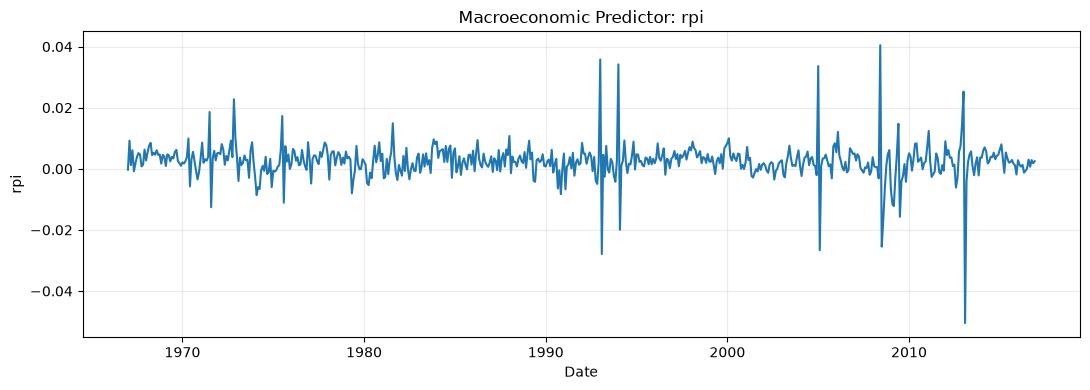

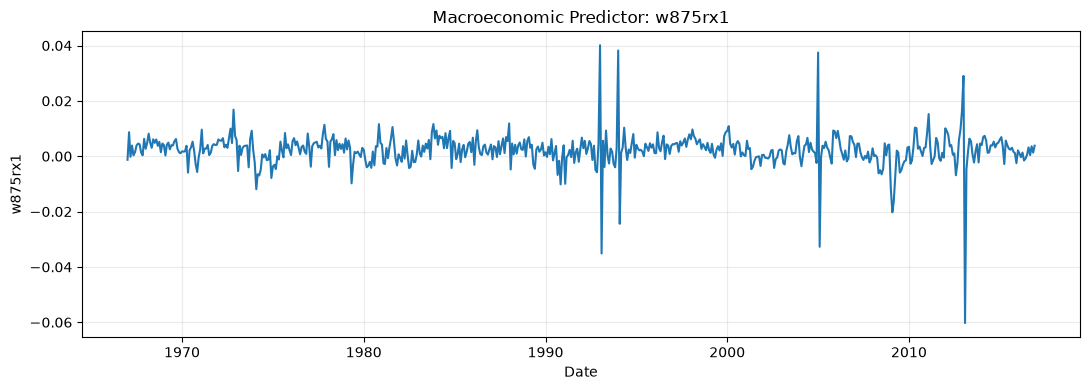

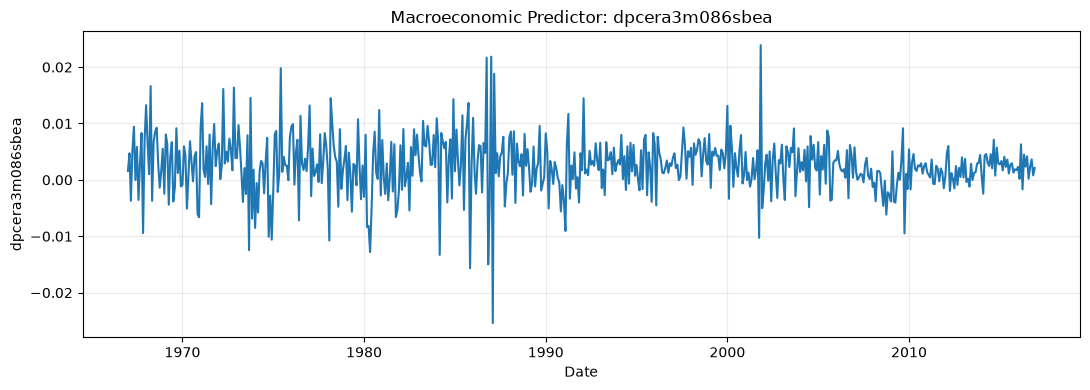

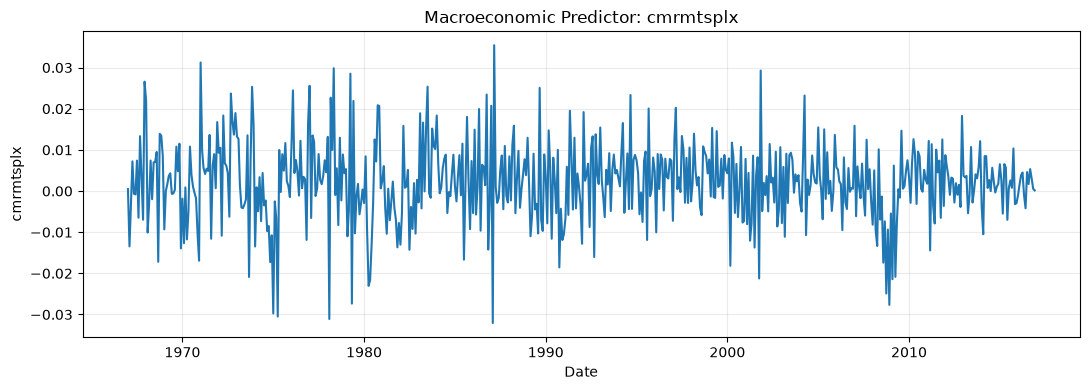

In [37]:
selected_macro = macro_feature_cols[:4]

print("Selected macro predictors:", selected_macro)

for c in selected_macro:
    plt.figure(figsize=(11, 4))
    plt.plot(macro[MACRO_DATE_COL], macro[c])
    plt.title(f"Macroeconomic Predictor: {c}")
    plt.xlabel("Date")
    plt.ylabel(c)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

This gives a more economically diverse view of the macro state:

- rpi — real personal income / real activity,

- indpro — industrial production,

- fedfunds — federal funds rate,

- svar — stock-market variance.

## 17. Stock–Macro Time Alignment

The stock-characteristic panel and the macroeconomic dataset are both monthly datasets, so they must be aligned on the same calendar before they are combined in later models.

This section compares the set of monthly dates available in the two datasets.

The objective is to determine:

- how many months are available in the stock dataset,
- how many months are available in the macro dataset,
- how many months are shared by both datasets,
- whether any months appear only in one dataset,
- the start and end dates of the common sample.

This alignment check is important because the later LSTM-based and adversarial models will use firm characteristics together with macroeconomic information.

If the two datasets were misaligned, the model could accidentally combine stock observations from one month with macroeconomic information from another month.

For the replication, we expect the stock and macro datasets to cover the same 600 monthly observations from January 1967 through December 2016.

Therefore, the ideal result is:

- 600 stock months,
- 600 macro months,
- 600 shared months,
- 0 stock-only months,
- 0 macro-only months.

Confirming this result ensures that the two information sets can later be merged safely by month.

In [38]:
# 17. Stock–macro time alignment

stock_months = set(
    stock[DATE_COL]
    .dropna()
    .unique()
)

macro_months = set(
    macro[MACRO_DATE_COL]
    .dropna()
    .unique()
)

shared_months = stock_months & macro_months
stock_only_months = stock_months - macro_months
macro_only_months = macro_months - stock_months

alignment_summary = pd.Series({
    "stock_months": len(stock_months),
    "macro_months": len(macro_months),
    "shared_months": len(shared_months),
    "stock_only_months": len(stock_only_months),
    "macro_only_months": len(macro_only_months),
}, name="months")

display(
    alignment_summary.to_frame()
)

if shared_months:
    print(
        "Common sample starts:",
        min(shared_months)
    )

    print(
        "Common sample ends  :",
        max(shared_months)
    )

,months
stock_months,600
macro_months,600
shared_months,600
stock_only_months,0
macro_only_months,0


Common sample starts: 1967-01-01 00:00:00
Common sample ends  : 2016-12-01 00:00:00


## 18. Verify the Saved Training, Validation, and Test Files

The first notebook saved the stock-characteristic and macroeconomic samples separately for the training, validation, and test periods.

This section verifies that those saved Parquet files exist and that they contain the expected number of observations and months.

The purpose is to ensure that later modeling notebooks can load fixed samples directly instead of reconstructing the split each time.

For each saved file, we report:

- the dataset name,
- the number of rows,
- the number of columns,
- the number of unique months,
- the first month,
- the last month.

The expected chronological structure is:

- Training: January 1967 through December 1986,
- Validation: January 1987 through December 1991,
- Test: January 1992 through December 2016.

For the macroeconomic dataset, each month contributes exactly one row.

For the stock-characteristic dataset, each month contains many stock observations, so the row counts are much larger.

If the saved files match these expected periods and dimensions, the data pipeline is ready for the modeling stage.

In [39]:
# 18. Verify saved train / validation / test files

split_files = {
    "stock_train": "retchar_train.parquet",
    "stock_validation": "retchar_validation.parquet",
    "stock_test": "retchar_test.parquet",
    "macro_train": "macro_train.parquet",
    "macro_validation": "macro_validation.parquet",
    "macro_test": "macro_test.parquet",
}

split_inventory = []

for label, filename in split_files.items():

    path = PROCESSED_DIR / filename

    if path.exists():

        df_tmp = pd.read_parquet(path)

        date_col = (
            DATE_COL
            if label.startswith("stock")
            else MACRO_DATE_COL
        )

        split_inventory.append({
            "dataset": label,
            "rows": len(df_tmp),
            "columns": df_tmp.shape[1],
            "months": df_tmp[date_col].nunique(),
            "start": df_tmp[date_col].min(),
            "end": df_tmp[date_col].max(),
        })

    else:

        split_inventory.append({
            "dataset": label,
            "rows": np.nan,
            "columns": np.nan,
            "months": np.nan,
            "start": pd.NaT,
            "end": pd.NaT,
        })

split_inventory = pd.DataFrame(
    split_inventory
)

display(split_inventory)

,dataset,rows,columns,months,start,end
0,stock_train,336113,48,240,1967-01-01,1986-12-01
1,stock_validation,132167,48,60,1987-01-01,1991-12-01
2,stock_test,750275,48,300,1992-01-01,2016-12-01
3,macro_train,240,179,240,1967-01-01,1986-12-01
4,macro_validation,60,179,60,1987-01-01,1991-12-01
5,macro_test,300,179,300,1992-01-01,2016-12-01


## 19. Save Exploratory Summary Tables

The exploratory analysis produces several tables that are useful for documenting the replication and for comparing the empirical sample with later modeling results.

Rather than recomputing these summaries in every notebook, we save the main exploratory outputs to the project's

`results/tables/`

directory.

The saved tables include:

- an overview of the stock and macroeconomic datasets,
- the monthly number of stock observations,
- summary statistics for the 46 firm characteristics,
- correlations between firm characteristics and returns,
- macroeconomic missing-value diagnostics,
- summary statistics for the 178 macroeconomic predictors,
- verification of the saved training, validation, and test samples.

Saving these outputs makes the research workflow more reproducible and provides a permanent record of the exploratory diagnostics used before model estimation.

These files are derived results rather than raw input data. They can later be used in the final replication report, figures, tables, and comparisons with the original paper.

In [40]:
# 19. Save exploratory summary tables

overview.to_csv(
    TABLES_DIR / "eda_dataset_overview.csv",
    index=False
)

monthly_stock_counts.to_csv(
    TABLES_DIR / "eda_monthly_stock_counts.csv"
)

char_summary.to_csv(
    TABLES_DIR / "eda_characteristic_summary.csv"
)

char_return_corr.to_csv(
    TABLES_DIR / "eda_characteristic_return_correlations.csv"
)

macro_missing.to_csv(
    TABLES_DIR / "eda_macro_missingness.csv"
)

macro_summary.to_csv(
    TABLES_DIR / "eda_macro_summary.csv"
)

split_inventory.to_csv(
    TABLES_DIR / "eda_split_inventory.csv",
    index=False
)

print("✓ Exploratory summary tables saved to:")
print(TABLES_DIR)

✓ Exploratory summary tables saved to:
/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables


In [41]:
# Verify saved EDA tables

saved_tables = sorted(TABLES_DIR.glob("eda_*.csv"))

for path in saved_tables:
    print(path.name)

eda_characteristic_return_correlations.csv
eda_characteristic_summary.csv
eda_dataset_overview.csv
eda_macro_missingness.csv
eda_macro_summary.csv
eda_monthly_stock_counts.csv
eda_split_inventory.csv


## 20. Exploratory Analysis Summary

The exploratory analysis confirms that the processed replication datasets are internally consistent and suitable for the modeling stage.

### Stock-characteristic panel

The stock dataset contains:

- 1,218,555 stock-month observations,
- 600 monthly periods,
- 46 firm characteristics,
- one return variable,
- a sample period from January 1967 through December 2016.

The number of stock observations varies across months, indicating an unbalanced cross-sectional panel.

Monthly stock returns are highly non-normal, with substantial positive skewness, extreme kurtosis, and a small number of very large positive and negative observations.

The 46 firm characteristics are already cross-sectionally rank-normalized. Their monthly means remain approximately zero and their monthly standard deviations remain close to the theoretical value associated with a uniform distribution over

\[
[-0.5, 0.5].
\]

Several characteristics are strongly correlated with economically related variables, but all 46 predictors are retained because the objective is to replicate the original multivariate modeling framework.

Univariate correlations between individual characteristics and returns are small, which reinforces the motivation for using multivariate and nonlinear asset-pricing models.

### Macroeconomic panel

The macroeconomic dataset contains:

- 600 monthly observations,
- 178 macroeconomic predictors,
- a sample period from January 1967 through December 2016.

The macroeconomic predictors vary substantially in scale and economic interpretation.

This heterogeneity will need to be handled carefully in later neural-network models. Any standardization should be estimated using the training sample only in order to avoid look-ahead bias.

### Data alignment

The stock and macroeconomic datasets are perfectly aligned over the full 1967–2016 sample.

The chronological samples are:

- Training: 1967–1986,
- Validation: 1987–1991,
- Test: 1992–2016.

The exploratory analysis therefore provides no evidence of a structural data problem that would prevent us from proceeding to model estimation.

The next stage of the replication is to construct a transparent linear benchmark before introducing the feedforward neural network, LSTM macro-state model, and adversarial asset-pricing architecture.